# Model Development

## Objective

The objective of this notebook is to train and evaluate the first machine learning model for predicting customer churn using the preprocessed dataset.

In [11]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

In [12]:
train_df = pd.read_csv("../data/processed/train_processed.csv")
test_df = pd.read_csv("../data/processed/test_processed.csv")

print("Training Dataset:", train_df.shape)
print("Testing Dataset :", test_df.shape)

Training Dataset: (5634, 48)
Testing Dataset : (1409, 48)


## Defining Features and Target

The processed datasets are separated into input features and the target variable before training the machine learning model.

In [13]:
X_train = train_df.drop("Churn Value", axis=1)
y_train = train_df["Churn Value"]

X_test = test_df.drop("Churn Value", axis=1)
y_test = test_df["Churn Value"]

print("Training Features :", X_train.shape)
print("Training Target   :", y_train.shape)

print("Testing Features  :", X_test.shape)
print("Testing Target    :", y_test.shape)

Training Features : (5634, 47)
Training Target   : (5634,)
Testing Features  : (1409, 47)
Testing Target    : (1409,)


## Logistic Regression Model

Logistic Regression is selected as the baseline classification algorithm. It is a simple, efficient, and interpretable model commonly used for binary classification problems such as customer churn prediction.

In [14]:
model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

## Training the Model

The Logistic Regression model is trained using the processed training dataset.

In [15]:
model.fit(X_train, y_train)

print("Model training completed successfully!")

Model training completed successfully!


c:\Users\ASUS\OneDrive\Masaüstü\Telecom-Customer-Retention-Intelligence-Platform\.venv\lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## Making Predictions

After training, the Logistic Regression model is used to predict customer churn on the testing dataset.

In [16]:
y_pred = model.predict(X_test)

print("Number of predictions:", len(y_pred))
print(y_pred[:10])

Number of predictions: 1409
[0 1 0 0 0 1 0 0 0 0]


## Model Evaluation

The Logistic Regression model is evaluated using accuracy, precision, recall, and F1 score. These metrics provide a broader assessment of model performance, especially for the churn class.

In [18]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

Accuracy : 0.8062
Precision: 0.6517
Recall   : 0.5802
F1 Score : 0.6139


## Classification Report

A detailed classification report is generated to evaluate the model's performance for each class separately.

In [19]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.65      0.58      0.61       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



## Confusion Matrix

The confusion matrix provides a detailed breakdown of correct and incorrect predictions, allowing us to identify how many churn and non-churn customers are classified correctly.

In [20]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[919 116]
 [157 217]]


## Confusion Matrix Visualization

The confusion matrix is visualized to better understand the distribution of correct and incorrect predictions.

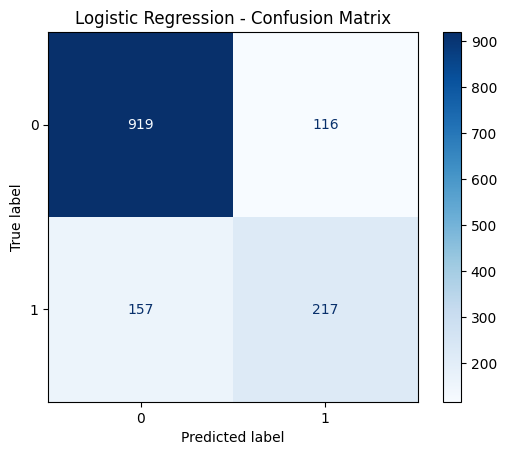

In [21]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(
    model,
    X_test,
    y_test,
    cmap="Blues"
)

plt.title("Logistic Regression - Confusion Matrix")
plt.show()

### Interpretation

The Logistic Regression model correctly classified **919 non-churn customers** and **217 churn customers**.

However, the model incorrectly predicted **116 non-churn customers** as churn (False Positives) and failed to identify **157 actual churn customers** (False Negatives).

Although the overall accuracy is satisfactory, the number of false negatives indicates that the model still misses a considerable portion of customers who are actually at risk of leaving. Reducing false negatives will be one of the main objectives when evaluating more advanced models such as Decision Tree, Random Forest, and XGBoost.

## ROC Curve and AUC Score

The Receiver Operating Characteristic (ROC) curve illustrates the trade-off between the True Positive Rate and False Positive Rate across different classification thresholds.

The Area Under the Curve (AUC) summarizes the model's overall ability to distinguish between churn and non-churn customers.